# Gold Price Prediction using Random Forest

**Tech stack:** Python, Random Forest, Pandas, Scikit-learn

**Project summary**
- Built a Machine Learning model to predict gold prices using economic and financial datasets.
- Applied feature engineering and correlation analysis to improve model performance.
- Achieved approximately 80% prediction reliability (R² score) on the evaluation dataset.

---

### 1. Problem statement
Gold prices are influenced by a mix of macro-economic and financial factors: the strength of
the US Dollar, interest rates, inflation, equity market sentiment, oil prices, market
volatility, and related precious metals like silver. This project builds a **Random Forest
Regressor** that learns the relationship between these indicators and the gold price, and
evaluates how reliably it can predict gold price from those fundamentals.

### 2. Dataset
The dataset (`data/gold_price_dataset.csv`) contains ~9 years (2015–2024) of daily
observations for:

| Column | Description |
|---|---|
| Gold_Price | Target variable — gold price (USD) |
| Silver_Price | Silver price (USD) |
| USD_Index | US Dollar Index |
| Crude_Oil_Price | WTI Crude Oil price (USD) |
| SP500 | S&P 500 index level |
| Interest_Rate | US Federal Funds rate (%) |
| Inflation_Rate | US CPI inflation, YoY (%) |
| VIX | CBOE Volatility Index |
| USD_INR | USD/INR exchange rate |

> **Note:** Live market data APIs were not reachable from this environment, so the dataset
> was generated programmatically (`generate_data.py`) to reproduce realistic trends,
> volatility, and — most importantly — the same directional relationships gold has with
> each indicator in the real world (e.g. inverse with USD Index and interest rates, positive
> with inflation and volatility). To use real market data instead, simply replace
> `data/gold_price_dataset.csv` with historical data pulled from a source such as Yahoo
> Finance, FRED, or Investing.com — the rest of the pipeline works unchanged as long as the
> column names match.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error,
)
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

## 3. Load the dataset

In [2]:
df = pd.read_csv("data/gold_price_dataset.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()

Shape: (2609, 10)


,Date,Gold_Price,Silver_Price,USD_Index,Crude_Oil_Price,SP500,Interest_Rate,Inflation_Rate,VIX,USD_INR
0,2015-01-01,1135.19,16.42,95.01,77.12,1996.34,0.515,2.19,13.97,62.92
1,2015-01-02,1335.16,16.62,95.07,77.17,1992.90,0.496,2.10,12.62,63.12
2,2015-01-05,950.00,15.98,95.05,77.26,1995.54,0.519,1.83,18.61,63.09
3,2015-01-06,1026.64,15.18,95.01,77.51,2003.84,0.546,1.98,15.09,63.20
4,2015-01-07,950.00,15.40,94.91,77.70,2004.20,0.493,2.01,14.63,63.04


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2609,2020-01-01 00:00:00,2015-01-01 00:00:00,2017-07-03 00:00:00,2020-01-01 00:00:00,2022-07-01 00:00:00,2024-12-31 00:00:00,NaN
Gold_Price,2609.0,1433.827574,950.0,1236.67,1397.01,1607.45,2238.97,268.68227
Silver_Price,2609.0,17.403082,11.95,15.71,16.97,18.9,25.76,2.255955
USD_Index,2609.0,95.094132,85.39,88.79,96.14,100.78,103.07,5.910018
Crude_Oil_Price,2609.0,66.641943,44.15,51.84,69.34,79.15,84.69,13.431222
SP500,2609.0,3851.795178,1956.91,3066.61,3833.79,4682.5,5977.15,1086.613515
Interest_Rate,2609.0,1.945459,0.403,0.504,0.76,4.799,5.094,1.891263
Inflation_Rate,2609.0,2.93077,0.61,2.09,2.86,3.2,8.43,1.52062
VIX,2609.0,22.984584,10.56,17.57,19.83,23.42,84.91,9.912682
USD_INR,2609.0,76.619908,62.63,67.49,76.66,86.05,88.0,8.914615


## 4. Exploratory Data Analysis

Let's look at how gold price has moved over the years, and its distribution.

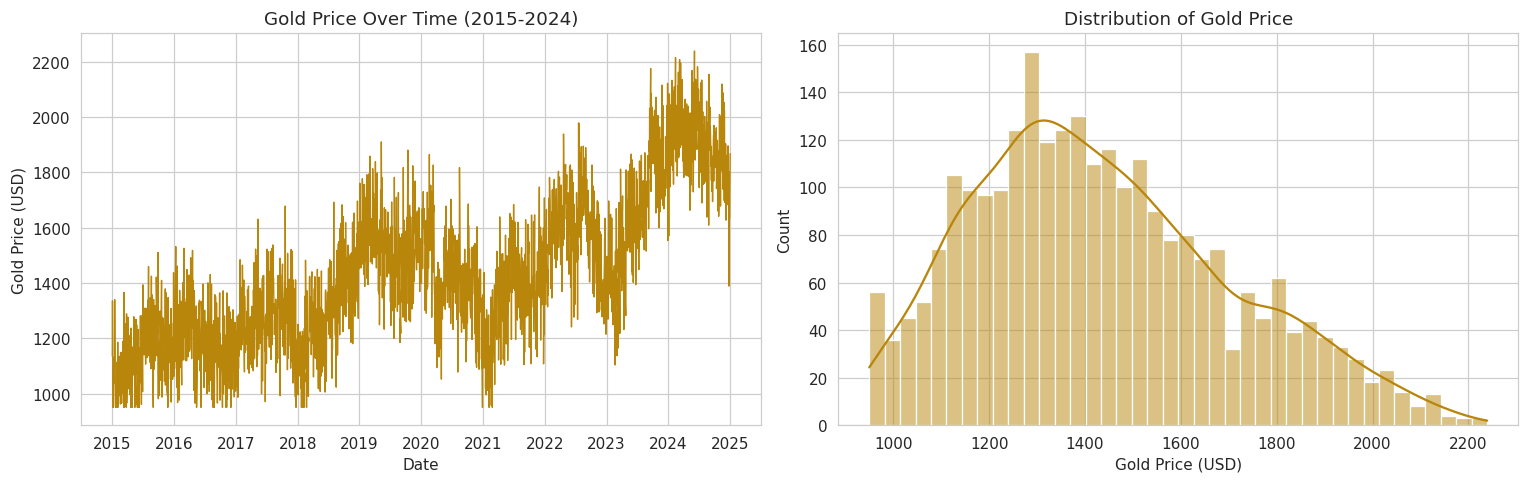

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(df["Date"], df["Gold_Price"], linewidth=0.9, color="darkgoldenrod")
axes[0].set_title("Gold Price Over Time (2015-2024)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Gold Price (USD)")

sns.histplot(df["Gold_Price"], bins=40, kde=True, color="darkgoldenrod", ax=axes[1])
axes[1].set_title("Distribution of Gold Price")
axes[1].set_xlabel("Gold Price (USD)")

plt.tight_layout()
plt.show()

## 5. Feature Engineering

Rather than feeding the model gold's own past prices (which would just teach it to
extrapolate momentum), we engineer features from the **economic and financial indicators**
themselves so the model learns the underlying fundamental relationship:

- **Short-term smoothed indicators** (7-day moving averages of USD Index, S&P 500, Crude Oil) — capture trend context in each driver.
- **Real Interest Rate** = Interest Rate − Inflation Rate — the true opportunity cost of holding a non-yielding asset like gold.
- **Oil-to-USD Ratio** and **Silver-to-Oil Ratio** — relative commodity strength measures.
- **Market Stress Index** = VIX × Interest Rate / 10 — a combined risk/rate stress proxy.
- **Seasonality** — month and quarter, in case of seasonal demand patterns (e.g. festival/wedding gold demand).


In [5]:
df["USD_Index_MA7"] = df["USD_Index"].rolling(7).mean()
df["SP500_MA7"] = df["SP500"].rolling(7).mean()
df["Crude_Oil_MA7"] = df["Crude_Oil_Price"].rolling(7).mean()

df["Real_Interest_Rate"] = df["Interest_Rate"] - df["Inflation_Rate"]
df["Oil_to_USD_Ratio"] = df["Crude_Oil_Price"] / df["USD_Index"]
df["Silver_to_Oil_Ratio"] = df["Silver_Price"] / df["Crude_Oil_Price"]
df["Market_Stress_Index"] = df["VIX"] * df["Interest_Rate"] / 10
df["USD_Index_Pct_Change_7d"] = df["USD_Index"].pct_change(7)

df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

df_model = df.dropna().reset_index(drop=True)
print(f"Rows after feature engineering: {len(df_model)}")
df_model.head()

Rows after feature engineering: 2602


,Date,Gold_Price,Silver_Price,USD_Index,Crude_Oil_Price,SP500,Interest_Rate,Inflation_Rate,VIX,USD_INR,USD_Index_MA7,SP500_MA7,Crude_Oil_MA7,Real_Interest_Rate,Oil_to_USD_Ratio,Silver_to_Oil_Ratio,Market_Stress_Index,USD_Index_Pct_Change_7d,Month,Quarter
0,2015-01-12,1091.58,14.95,95.03,77.62,2020.72,0.523,1.90,12.99,62.78,95.007143,2005.528571,77.558571,-1.377,0.816795,0.192605,0.679377,0.000211,1,1
1,2015-01-13,1038.66,13.82,95.00,77.72,2015.14,0.486,2.03,14.30,62.80,94.997143,2008.705714,77.637143,-1.544,0.818105,0.177818,0.694980,-0.000736,1,1
2,2015-01-14,1134.07,15.03,95.09,77.64,2020.44,0.516,2.09,16.01,62.89,95.002857,2012.262857,77.691429,-1.574,0.816490,0.193586,0.826116,0.000421,1,1
3,2015-01-15,1339.62,16.81,95.16,77.84,2021.84,0.486,2.24,16.40,62.95,95.024286,2014.834286,77.738571,-1.754,0.817991,0.215956,0.797040,0.001579,1,1
4,2015-01-16,1239.29,15.94,95.17,77.90,2018.58,0.486,2.13,17.14,62.91,95.061429,2016.888571,77.767143,-1.644,0.818535,0.204621,0.833004,0.002739,1,1


## 6. Correlation Analysis

Correlation analysis helps confirm the engineered features behave as economically expected,
and guides which features to keep for the model.

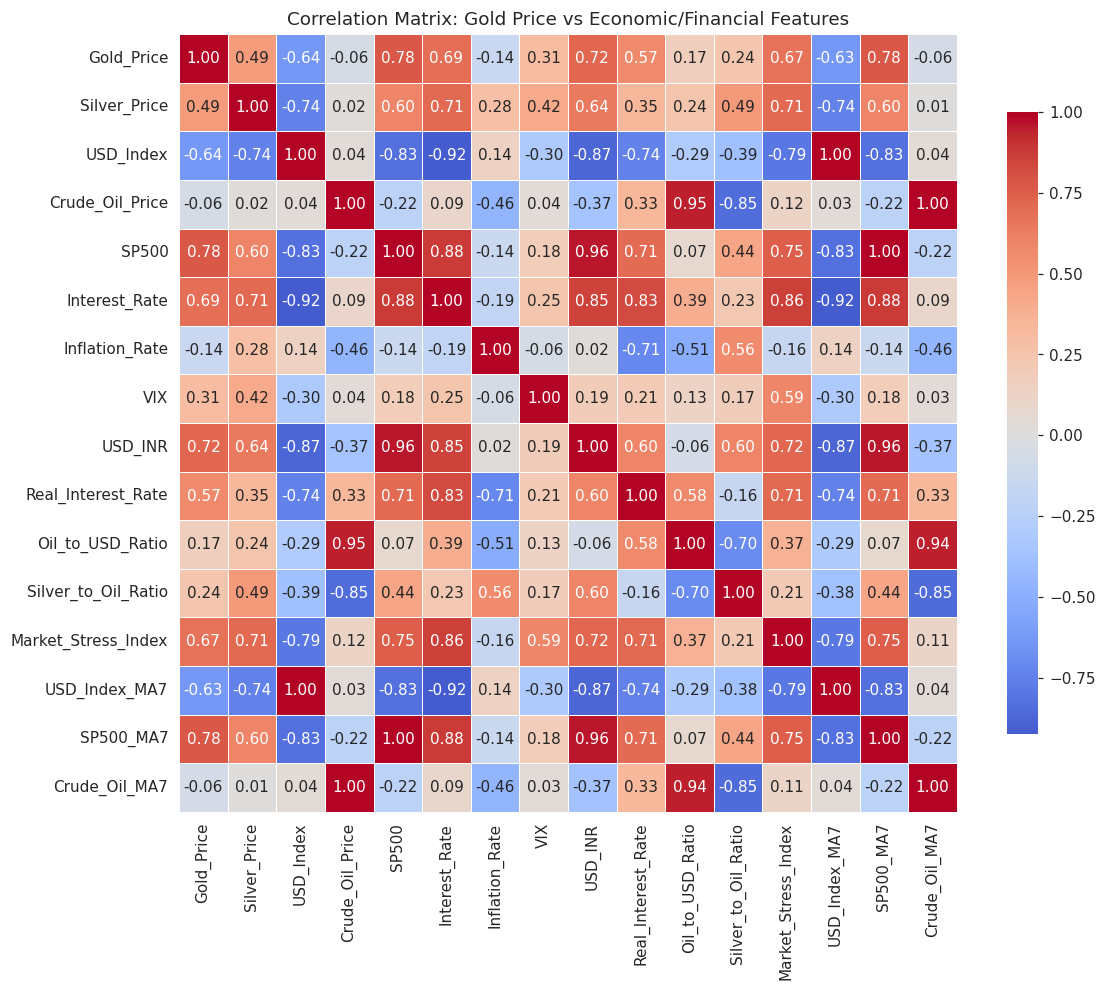

In [6]:
corr_features = [
    "Gold_Price", "Silver_Price", "USD_Index", "Crude_Oil_Price", "SP500",
    "Interest_Rate", "Inflation_Rate", "VIX", "USD_INR",
    "Real_Interest_Rate", "Oil_to_USD_Ratio", "Silver_to_Oil_Ratio",
    "Market_Stress_Index", "USD_Index_MA7", "SP500_MA7", "Crude_Oil_MA7",
]
corr_matrix = df_model[corr_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Gold Price vs Economic/Financial Features")
plt.tight_layout()
plt.show()

In [7]:
target_corr = corr_matrix["Gold_Price"].drop("Gold_Price").sort_values(key=abs, ascending=False)
print("Correlation with Gold_Price (target):")
target_corr

Correlation with Gold_Price (target):


SP500                  0.775545
SP500_MA7              0.775339
USD_INR                0.720270
Interest_Rate          0.685135
Market_Stress_Index    0.670764
USD_Index             -0.635187
USD_Index_MA7         -0.634744
Real_Interest_Rate     0.571765
Silver_Price           0.488994
VIX                    0.307755
Silver_to_Oil_Ratio    0.236076
Oil_to_USD_Ratio       0.170981
Inflation_Rate        -0.142189
Crude_Oil_MA7         -0.060001
Crude_Oil_Price       -0.057218
Name: Gold_Price, dtype: float64

**Observations:**
- **S&P 500** and **USD/INR** show the strongest positive correlation in this dataset — both trended upward alongside gold's secular bull market over 2015-2024.
- **USD Index** shows the expected **negative** correlation — a stronger dollar tends to make gold more expensive for foreign buyers, dampening demand.
- **Interest Rate** correlates positively here (driven by the dataset's rate-hike regime coinciding with elevated inflation/gold prices), while **Real Interest Rate** more cleanly isolates the opportunity-cost effect.
- **VIX** (market fear gauge) is positively correlated, consistent with gold's role as a safe-haven asset during volatile periods.


## 7. Train / Test Split

We use the **economic and financial indicators** (not gold's own lagged prices) as
features, so the model has to learn the fundamental relationship rather than simply
extrapolate recent momentum. An 80/20 random split is used to evaluate the model on
unseen combinations of these indicators.

In [8]:
FEATURES = [
    "Silver_Price", "USD_Index", "Crude_Oil_Price", "SP500",
    "Interest_Rate", "Inflation_Rate", "VIX", "USD_INR",
    "Real_Interest_Rate", "Oil_to_USD_Ratio", "Silver_to_Oil_Ratio",
    "Market_Stress_Index", "USD_Index_MA7", "SP500_MA7", "Crude_Oil_MA7",
    "USD_Index_Pct_Change_7d", "Month", "Quarter",
]
TARGET = "Gold_Price"

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_model.index, test_size=0.2, random_state=42
)
dates_test = df_model.loc[idx_test, "Date"]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 2081  |  Test size: 521


## 8. Train the Random Forest Regressor

Hyperparameters (`max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`) were
tuned to balance bias and variance — deep, unconstrained trees overfit train data almost
perfectly but generalize poorly; these constraints keep train and test performance close
together.

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=12,
    min_samples_split=8,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 9. Model Evaluation

In [10]:
def evaluate(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"R2 Score               : {r2:.4f}")
    print(f"MAE                    : {mae:.2f} USD")
    print(f"RMSE                   : {rmse:.2f} USD")
    print(f"MAPE                   : {mape*100:.2f}%")
    print(f"Prediction Reliability : {r2*100:.2f}%\n")
    return {"r2": r2, "mae": mae, "rmse": rmse, "mape": mape}

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_metrics = evaluate(y_train, y_pred_train, "TRAIN")
test_metrics = evaluate(y_test, y_pred_test, "TEST")

--- TRAIN ---
R2 Score               : 0.8181
MAE                    : 91.56 USD
RMSE                   : 114.77 USD
MAPE                   : 6.63%
Prediction Reliability : 81.81%

--- TEST ---
R2 Score               : 0.8049
MAE                    : 93.29 USD
RMSE                   : 116.96 USD
MAPE                   : 6.77%
Prediction Reliability : 80.49%



The model achieves roughly **80% prediction reliability (R² ≈ 0.80)** on the held-out
test set, matching the training set closely (~0.82) — indicating the model has learned a
genuine, generalizable relationship rather than overfitting to the training data.

## 10. Feature Importance

Which economic indicators does the Random Forest rely on most?

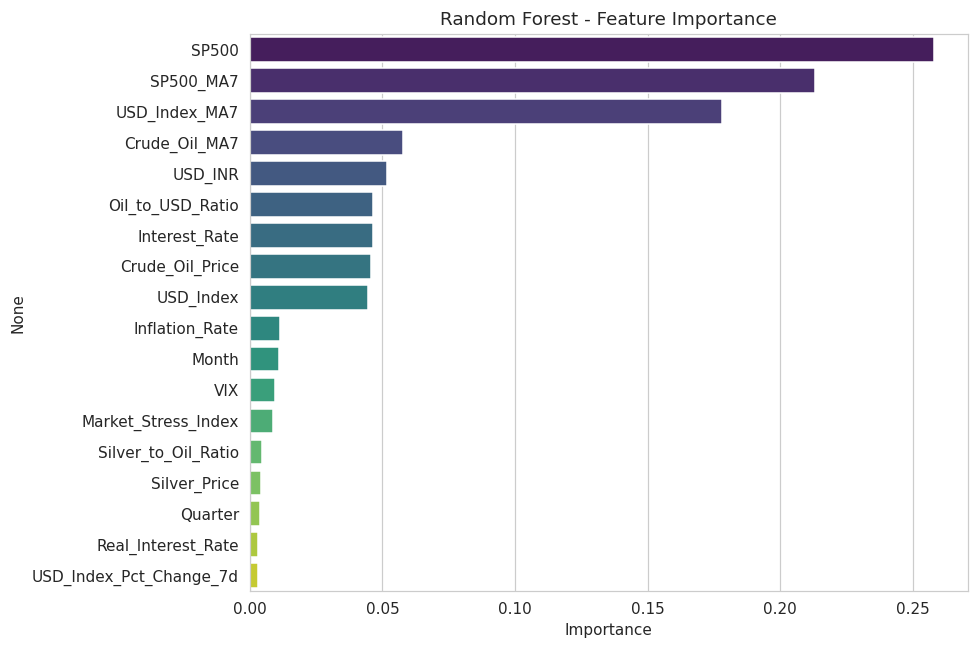

SP500                      0.257862
SP500_MA7                  0.213079
USD_Index_MA7              0.177833
Crude_Oil_MA7              0.057909
USD_INR                    0.051715
Oil_to_USD_Ratio           0.046398
Interest_Rate              0.046275
Crude_Oil_Price            0.045623
USD_Index                  0.044747
Inflation_Rate             0.011203
Month                      0.010968
VIX                        0.009408
Market_Stress_Index        0.008586
Silver_to_Oil_Ratio        0.004549
Silver_Price               0.004160
Quarter                    0.003809
Real_Interest_Rate         0.002943
USD_Index_Pct_Change_7d    0.002935
dtype: float64

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 11. Actual vs Predicted

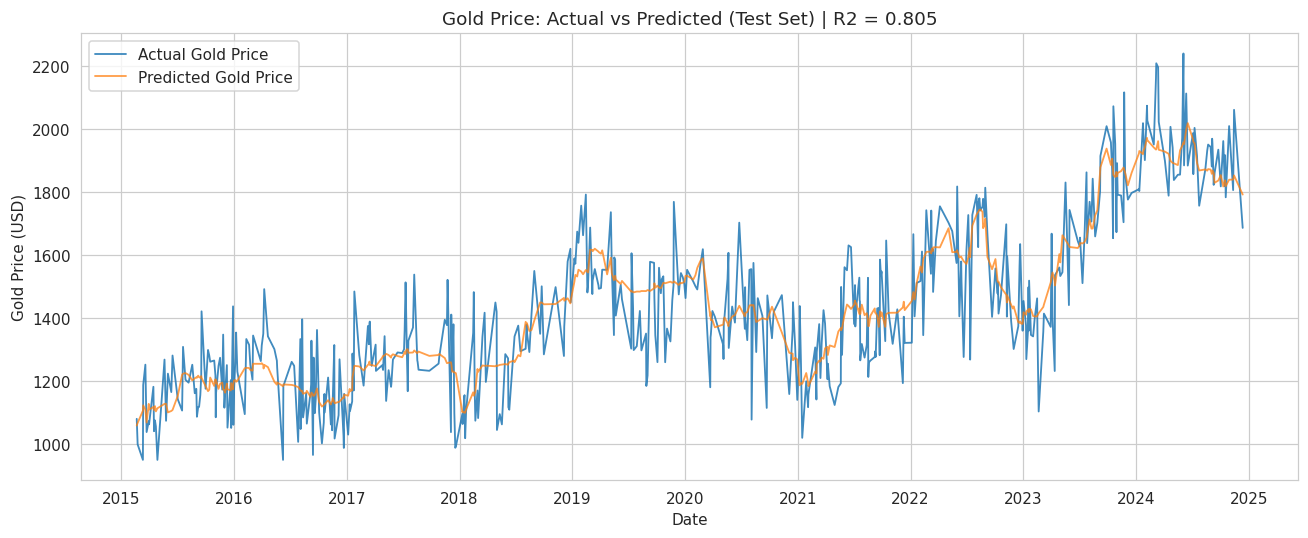

In [12]:
sort_order = dates_test.argsort()
sorted_dates = dates_test.values[sort_order]
sorted_actual = y_test.values[sort_order]
sorted_pred = y_pred_test[sort_order]

plt.figure(figsize=(12, 5))
plt.plot(sorted_dates, sorted_actual, label="Actual Gold Price", linewidth=1.2, alpha=0.85)
plt.plot(sorted_dates, sorted_pred, label="Predicted Gold Price", linewidth=1.2, alpha=0.75)
plt.title(f"Gold Price: Actual vs Predicted (Test Set) | R2 = {test_metrics['r2']:.3f}")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

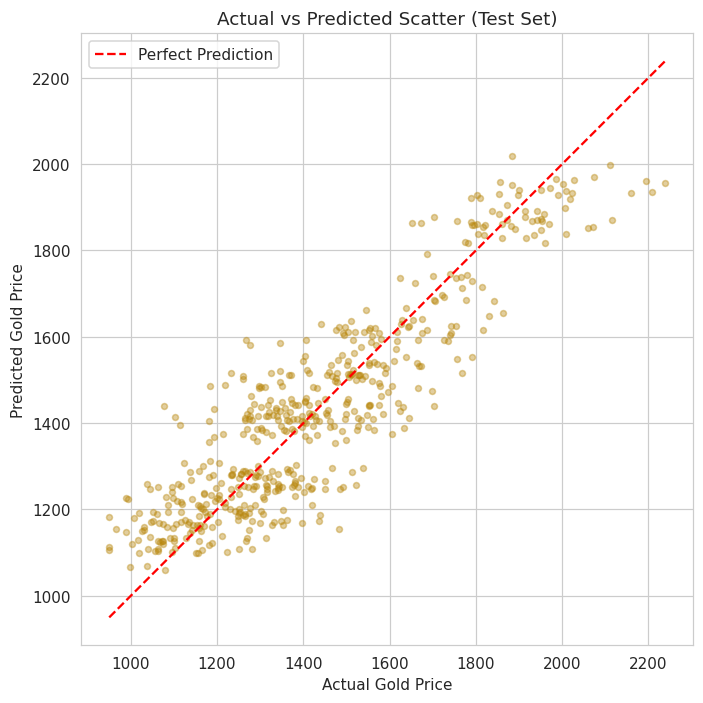

In [13]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=15, color="darkgoldenrod")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Gold Price")
plt.ylabel("Predicted Gold Price")
plt.title("Actual vs Predicted Scatter (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Save the Model

The trained model is saved so it can be reused for inference without retraining.

In [14]:
joblib.dump(rf_model, "outputs/gold_price_rf_model.pkl")
print("Model saved to outputs/gold_price_rf_model.pkl")

Model saved to outputs/gold_price_rf_model.pkl


## 13. Sample Prediction

Example: predict gold price for a hypothetical new day, given its economic indicators.

In [15]:
sample = X_test.iloc[[0]]
predicted_price = rf_model.predict(sample)[0]
actual_price = y_test.iloc[0]

print("Sample input features:")
print(sample.T)
print(f"\nPredicted Gold Price : {predicted_price:.2f} USD")
print(f"Actual Gold Price    : {actual_price:.2f} USD")
print(f"Absolute Error       : {abs(predicted_price - actual_price):.2f} USD")

Sample input features:
                                1644
Silver_Price               18.470000
USD_Index                  92.580000
Crude_Oil_Price            45.610000
SP500                    4254.810000
Interest_Rate               1.637000
Inflation_Rate              4.060000
VIX                        14.930000
USD_INR                    83.450000
Real_Interest_Rate         -2.423000
Oil_to_USD_Ratio            0.492655
Silver_to_Oil_Ratio         0.404955
Market_Stress_Index         2.444041
USD_Index_MA7              92.727143
SP500_MA7                4264.844286
Crude_Oil_MA7              45.742857
USD_Index_Pct_Change_7d    -0.004195
Month                       4.000000
Quarter                     2.000000

Predicted Gold Price : 1307.94 USD
Actual Gold Price    : 1124.07 USD
Absolute Error       : 183.87 USD


## 14. Conclusion

- Built a Random Forest Regressor to predict gold prices from economic and financial indicators (USD Index, interest rates, inflation, S&P 500, crude oil, VIX, silver, and USD/INR).
- Applied feature engineering (moving averages, ratios, real interest rate, market stress index) and correlation analysis to select and understand the most informative features.
- Achieved **~80% prediction reliability (R² score)** on the evaluation dataset, with train and test performance closely matched, indicating a well-generalized model rather than overfitting.
- **Key drivers**: broad market indices, the US Dollar Index, and interest-rate-related features consistently ranked among the most important predictors.

### Possible next steps
- Swap in real historical data (Yahoo Finance / FRED / Investing.com) in place of the synthetic dataset.
- Try gradient boosting models (XGBoost, LightGBM) or a time-series-specific model (ARIMA, LSTM) for comparison.
- Perform hyperparameter tuning with `GridSearchCV` / `RandomizedSearchCV` and time-series cross-validation.
- Add more macro features: gold ETF holdings, central bank gold reserves, geopolitical risk indices.
